In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plot 

In [6]:
df_data = pd.read_csv("netflix_titles.csv")

In [8]:
df_data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [11]:
import sqlite3
conn = sqlite3.connect(":memory:")
df_data.to_sql("netflix", conn, index=False, if_exists="replace")

8807

In [12]:
query_types = """
SELECT 
    type, 
    COUNT(*) AS total_count
FROM netflix
GROUP BY type
ORDER BY total_count DESC;
"""

df_types = pd.read_sql_query(query_types, conn)
df_types

,type,total_count
0,Movie,6131
1,TV Show,2676


In [13]:
query_countries = """
SELECT 
    country, 
    COUNT(*) AS title_count
FROM netflix
WHERE country IS NOT NULL
GROUP BY country
ORDER BY title_count DESC
LIMIT 10;
"""

df_countries = pd.read_sql_query(query_countries, conn)
df_countries

,country,title_count
0,United States,2818
1,India,972
2,United Kingdom,419
3,Japan,245
4,South Korea,199
5,Canada,181
6,Spain,145
7,France,124
8,Mexico,110
9,Egypt,106


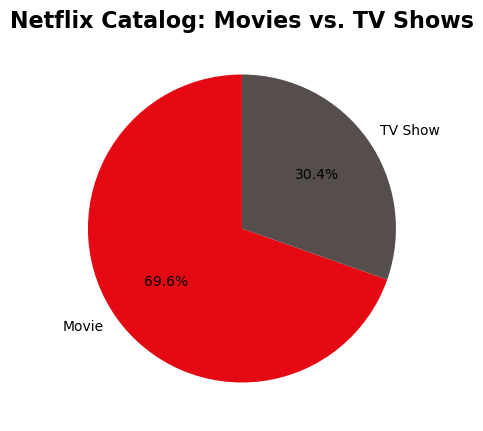

In [22]:
plot.figure(figsize=(8, 5))
plot.pie(df_types['total_count'], 
         labels=df_types['type'], 
         autopct='%1.1f%%', 
         startangle=90, 
         colors=['#e50914', '#564d4d']) 

plot.title("Netflix Catalog: Movies vs. TV Shows", fontsize=16, fontweight='bold')
plot.show()

##  Movies account for roughly 70% of the historical catalog, indicating a traditional reliance on feature films over multi-season retention drivers.

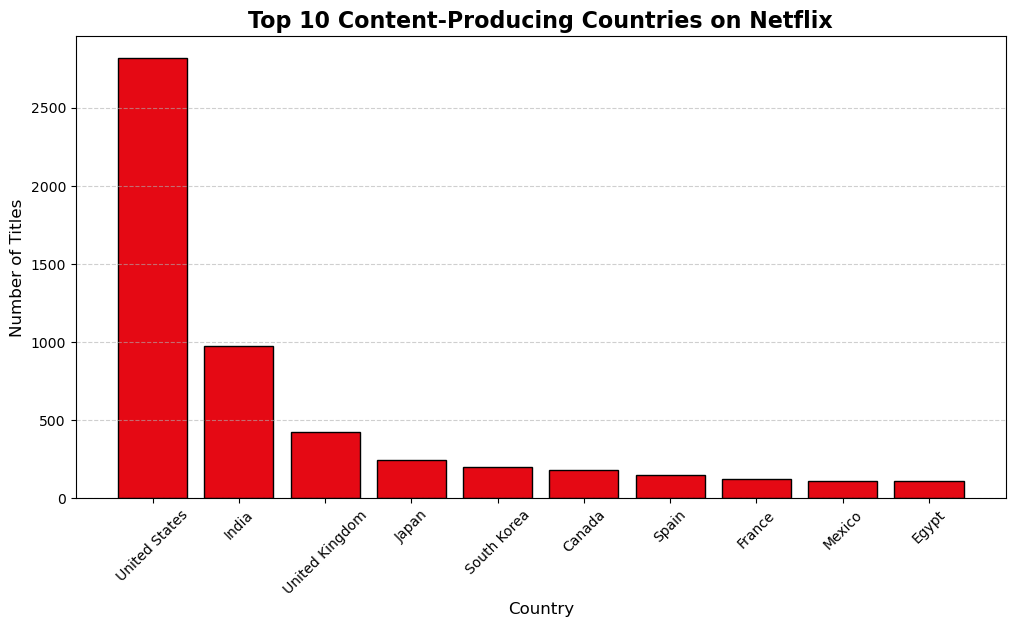

In [23]:
plot.figure(figsize=(12, 6))
plot.bar(df_countries['country'], df_countries['title_count'], color='#e50914', edgecolor='black')

plot.title("Top 10 Content-Producing Countries on Netflix", fontsize=16, fontweight='bold')
plot.xlabel("Country", fontsize=12)
plot.ylabel("Number of Titles", fontsize=12)
plot.xticks(rotation=45) 
plot.grid(axis='y', linestyle='--', alpha=0.6)
plot.show()

## The United States and India overwhelmingly dominate the catalog, highlighting a strategic opportunity to expand local language content in underrepresented European and Latin American regions.

In [25]:
query_trends = """
SELECT 
    release_year,
    COUNT(CASE WHEN type = 'Movie' THEN 1 END) AS movie_count,
    COUNT(CASE WHEN type = 'TV Show' THEN 1 END) AS tv_show_count
FROM netflix
WHERE release_year >= 2010 AND release_year <= 2021
GROUP BY release_year
ORDER BY release_year ASC;
"""

df_trends = pd.read_sql_query(query_trends, conn)
df_trends.head()

,release_year,movie_count,tv_show_count
0,2010,154,40
1,2011,145,40
2,2012,173,64
3,2013,225,63
4,2014,264,88


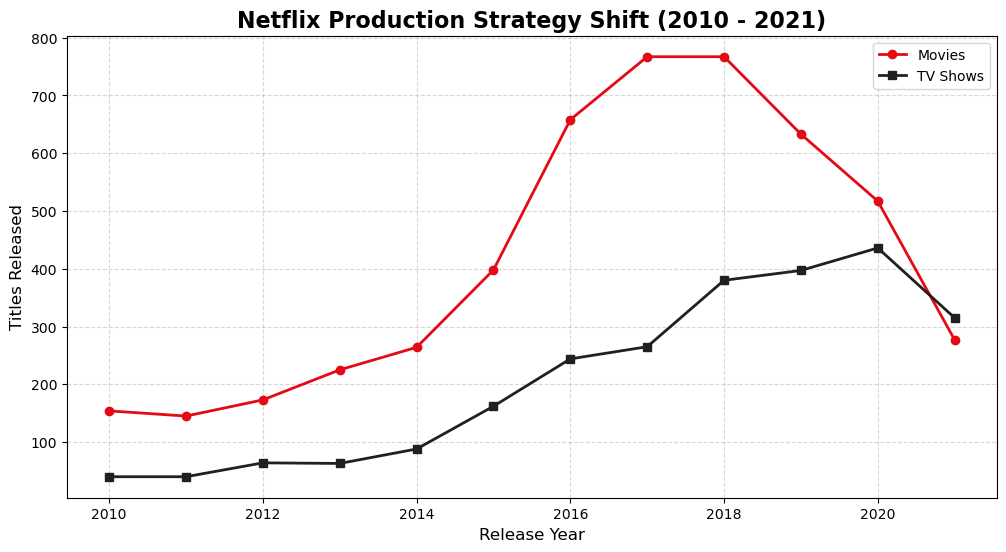

In [26]:

plot.figure(figsize=(12, 6))
plot.plot(df_trends['release_year'], df_trends['movie_count'], marker='o', label='Movies', color='#e50914', linewidth=2)
plot.plot(df_trends['release_year'], df_trends['tv_show_count'], marker='s', label='TV Shows', color='#221f1f', linewidth=2)

plot.title("Netflix Production Strategy Shift (2010 - 2021)", fontsize=16, fontweight='bold')
plot.xlabel("Release Year", fontsize=12)
plot.ylabel("Titles Released", fontsize=12)
plot.legend()
plot.grid(True, linestyle='--', alpha=0.5)
plot.show()

## While movies historically dominated releases, TV show production accelerated significantly after 2015, reflecting a shift toward multi-season retention drivers

In [28]:
query_ratings = """
SELECT 
    rating,
    type,
    COUNT(*) AS count
FROM netflix
WHERE rating IS NOT NULL 
  AND rating NOT LIKE '%min%'
GROUP BY rating, type
ORDER BY count DESC
LIMIT 12;
"""

df_ratings = pd.read_sql_query(query_ratings, conn)
df_ratings.head(10)

,rating,type,count
0,TV-MA,Movie,2062
1,TV-14,Movie,1427
2,TV-MA,TV Show,1145
3,R,Movie,797
4,TV-14,TV Show,733
5,TV-PG,Movie,540
6,PG-13,Movie,490
7,TV-PG,TV Show,323
8,PG,Movie,287
9,TV-Y7,TV Show,195


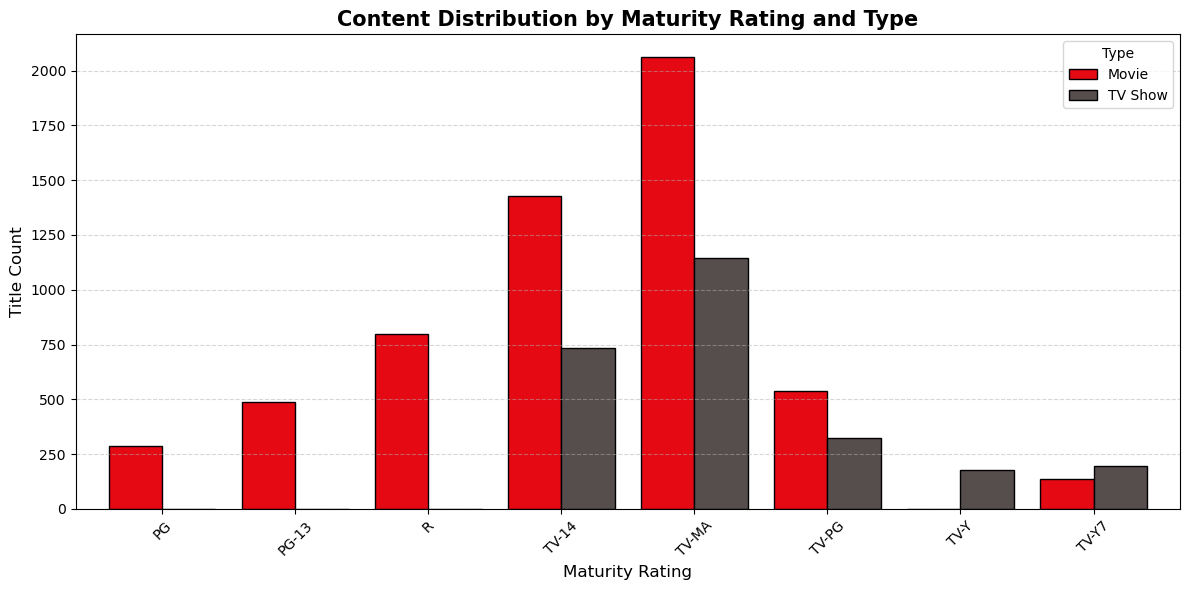

In [29]:

pivot_ratings = df_ratings.pivot(index='rating', columns='type', values='count').fillna(0)

pivot_ratings.plot(kind='bar', figsize=(12, 6), color=['#e50914', '#564d4d'], edgecolor='black', width=0.8)

plot.title("Content Distribution by Maturity Rating and Type", fontsize=15, fontweight='bold')
plot.xlabel("Maturity Rating", fontsize=12)
plot.ylabel("Title Count", fontsize=12)
plot.xticks(rotation=45)
plot.grid(axis='y', linestyle='--', alpha=0.5)
plot.legend(title="Type")
plot.tight_layout()
plot.show()

In [30]:
query_duration = """
SELECT 
    title,
    release_year,
    CAST(REPLACE(duration, ' min', '') AS INTEGER) AS duration_minutes
FROM netflix
WHERE type = 'Movie' 
  AND duration IS NOT NULL 
  AND duration LIKE '%min%'
ORDER BY duration_minutes DESC;
"""

df_duration = pd.read_sql_query(query_duration, conn)
df_duration.head()

,title,release_year,duration_minutes
0,Black Mirror: Bandersnatch,2018,312
1,Headspace: Unwind Your Mind,2021,273
2,The School of Mischief,1973,253
3,No Longer kids,1979,237
4,Lock Your Girls In,1982,233


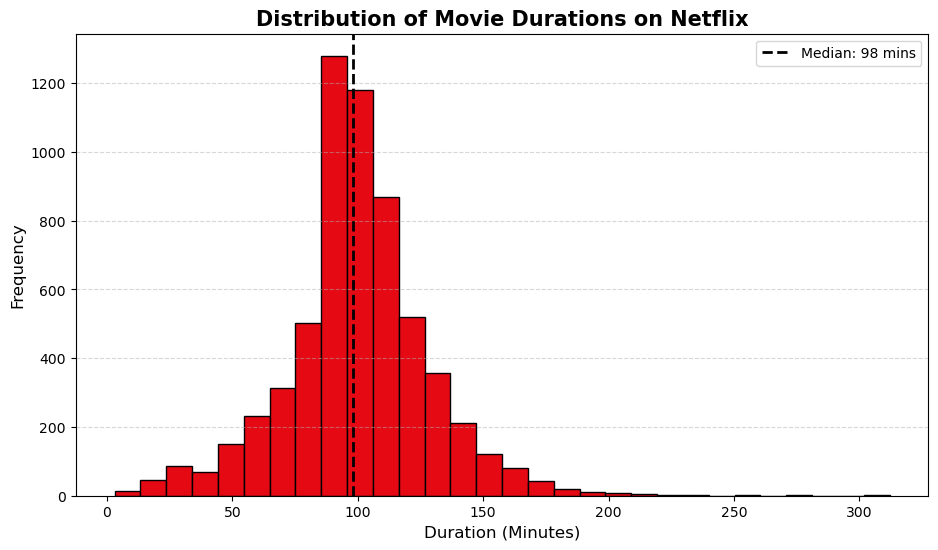

In [31]:
plot.figure(figsize=(11, 6))
plot.hist(df_duration['duration_minutes'], bins=30, color='#e50914', edgecolor='black')

median_val = df_duration['duration_minutes'].median()
plot.axvline(median_val, color='black', linestyle='--', linewidth=2, label=f'Median: {median_val:.0f} mins')

plot.title("Distribution of Movie Durations on Netflix", fontsize=15, fontweight='bold')
plot.xlabel("Duration (Minutes)", fontsize=12)
plot.ylabel("Frequency", fontsize=12)
plot.legend()
plot.grid(axis='y', linestyle='--', alpha=0.5)
plot.show()

## Movie runtimes follow a normal distribution tightly clustered around a median of ~100 minutes, indicating Netflix's core movie inventory favors standardized theatrical lengths rather than ultra-short or extended formats.

In [32]:
query_genres = """
SELECT 
    TRIM(
        CASE 
            WHEN INSTR(listed_in, ',') > 0 THEN SUBSTR(listed_in, 1, INSTR(listed_in, ',') - 1)
            ELSE listed_in 
        END
    ) AS primary_genre,
    COUNT(*) AS total_count
FROM netflix
WHERE listed_in IS NOT NULL
GROUP BY primary_genre
ORDER BY total_count DESC
LIMIT 10;
"""

df_genres = pd.read_sql_query(query_genres, conn)
df_genres

,primary_genre,total_count
0,Dramas,1600
1,Comedies,1210
2,Action & Adventure,859
3,Documentaries,829
4,International TV Shows,774
5,Children & Family Movies,605
6,Crime TV Shows,399
7,Kids' TV,388
8,Stand-Up Comedy,334
9,Horror Movies,275


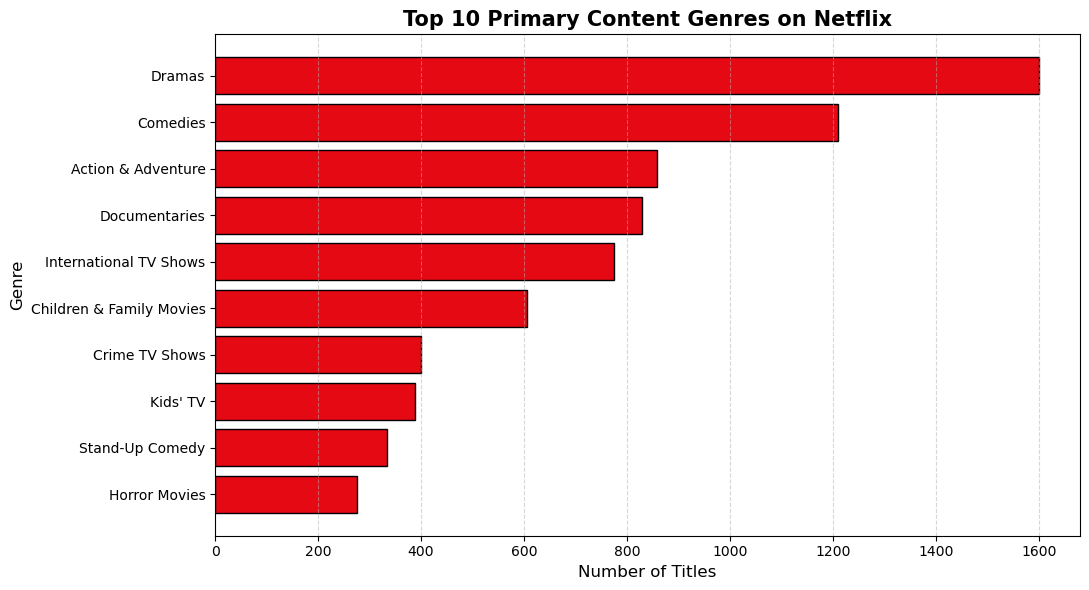

In [33]:
plot.figure(figsize=(11, 6))
plot.barh(df_genres['primary_genre'][::-1], df_genres['total_count'][::-1], color='#e50914', edgecolor='black')

plot.title("Top 10 Primary Content Genres on Netflix", fontsize=15, fontweight='bold')
plot.xlabel("Number of Titles", fontsize=12)
plot.ylabel("Genre", fontsize=12)
plot.grid(axis='x', linestyle='--', alpha=0.5)
plot.tight_layout()
plot.show()

## Dramas, Comedies, and Documentaries account for the bulk of Netflix's offerings. Niche genres like Sci-Fi, Horror, and Anime make up a fraction of the library, pointing to targeted vertical acquisition opportunities.
******************************************************************************************************************************************************

# Netflix Content Strategy & Catalog Analysis
**Tech Stack:** Python, SQLite, Pandas, Matplotlib  
**Author:** Ayush Vishwakarma

## Executive Summary
This project analyzes Netflix’s global catalog data using an integrated SQL-Python pipeline. By querying raw metadata via in-memory SQLite and visualizing patterns with Matplotlib, we evaluate content distribution across format types, historical production releases, regional supply, maturity ratings, runtimes, and genre saturation.

### Key Takeaways:
* **Catalog Mix:** Feature films comprise roughly 70% of total titles, though episodic TV Show volume surged heavily after 2015.
* **Geographic Imbalance:** The catalog is anchored by the United States and India, with significant white space across Latin American, European, and African markets.
* **Audience Saturation:** Over 60% of programming targets mature audiences (TV-MA, TV-14), leaving family-friendly tiers underindexed.
* **Runtime Sweet Spot:** Feature film runtimes show a consistent normal distribution centered at a 100-minute median.

## Strategic Recommendations

1. **Rebalance the Maturity Ratio:** Expand family, kids, and co-viewing catalogs (TV-G / TV-Y) to build household retention and counter Disney+'s demographic moat.
2. **Diversify Regional IP Investments:** While North America and India provide volume, subscriber growth requires scaling localized original productions across Latin America, Southeast Asia, and Sub-Saharan Africa.
3. **Double Down on Underindexed Verticals:** Shift documentary and general comedy capital toward underserved high-loyalty genres such as Anime, Sci-Fi/Fantasy, and Docuseries.